# Ontology Evolution Metrics Dashboard

Visualize structural and change metrics across ontology evolution iterations.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ontology_hydra.metrics import (
    compute_structural_metrics,
)
from ontology_hydra.ontology.models import BASE_ONTOLOGY, Ontology
from ontology_hydra.utils.cache import DirectoryCache

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 4)

Matplotlib is building the font cache; this may take a moment.


## Load Cache Data

In [9]:
CACHE_PATH = Path('.hydra/test/out/cache')
assert CACHE_PATH.exists(), f"Cache path {CACHE_PATH} does not exist"

cache = DirectoryCache(CACHE_PATH)

# Determine number of epochs
n_epochs = 0
for i in range(1000):
    if not cache.exists((i, 'ontology.json')):
        n_epochs = i
        break

print(f"Found {n_epochs} epochs")

Found 18 epochs


## Compute Metrics

In [10]:
structural_records = []
change_records = []
operation_records = []

prev_ontology = BASE_ONTOLOGY

for epoch in range(n_epochs):
    # Load ontology
    ontology_json = cache.read((epoch, 'ontology.json'))
    if not ontology_json:
        continue
    ontology = Ontology.model_validate_json(ontology_json)
    
    # Structural metrics
    sm = compute_structural_metrics(ontology)
    structural_records.append({
        'epoch': epoch,
        **sm.model_dump()
    })
    
    # Load operations
    ops_json = cache.read((epoch, 'ops.json'))
    if ops_json:
        ops_data = json.loads(ops_json)
        ops_list = ops_data.get('ops', [])
        
        # Count operations by type
        for op in ops_list:
            operation_records.append({
                'epoch': epoch,
                'op_type': op['op']
            })
        
        # Change metrics (compare to previous epoch)
        if epoch > 0:
            # We need to create operation objects for count_operations
            # For now, just count from raw data
            op_counts = {}
            for op in ops_list:
                op_type = op['op']
                op_counts[op_type] = op_counts.get(op_type, 0) + 1
            
            total_add = op_counts.get('add_class', 0) + op_counts.get('add_data_prop', 0) + op_counts.get('add_object_prop', 0)
            total_update = op_counts.get('update_class', 0) + op_counts.get('update_data_prop', 0) + op_counts.get('update_object_prop', 0)
            total_delete = op_counts.get('del_class', 0) + op_counts.get('del_data_prop', 0) + op_counts.get('del_object_prop', 0)
            total_merge = op_counts.get('merge_classes', 0)
            total = total_add + total_update + total_delete + total_merge
            
            change_records.append({
                'epoch': epoch,
                'total_ops': total,
                'total_add': total_add,
                'total_update': total_update,
                'total_delete': total_delete,
                'total_merge': total_merge,
                'add_ratio': total_add / total if total > 0 else 0,
                'non_additive_ratio': (total_update + total_delete + total_merge) / total if total > 0 else 0,
            })
    
    prev_ontology = ontology

df_structural = pd.DataFrame(structural_records)
df_changes = pd.DataFrame(change_records)
df_operations = pd.DataFrame(operation_records)

print(f"Structural metrics: {len(df_structural)} epochs")
print(f"Change metrics: {len(df_changes)} epochs")
print(f"Operations: {len(df_operations)} total")

Structural metrics: 18 epochs
Change metrics: 17 epochs
Operations: 356 total


## Structural Metrics Over Time

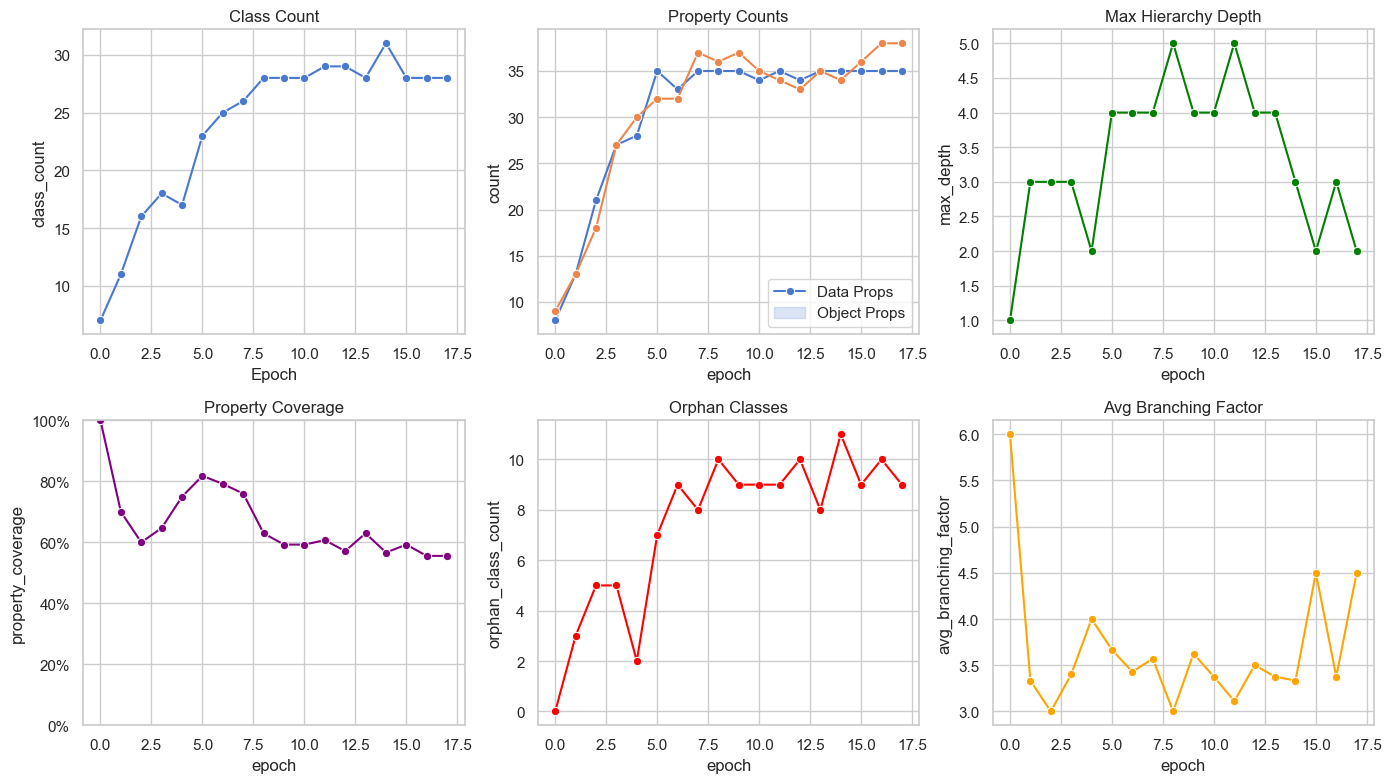

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Class count
sns.lineplot(data=df_structural, x='epoch', y='class_count', ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Class Count')
axes[0, 0].set_xlabel('Epoch')

# Property counts
df_props = df_structural.melt(id_vars=['epoch'], value_vars=['data_property_count', 'object_property_count'],
                               var_name='property_type', value_name='count')
sns.lineplot(data=df_props, x='epoch', y='count', hue='property_type', ax=axes[0, 1], marker='o')
axes[0, 1].set_title('Property Counts')
axes[0, 1].legend(title='', labels=['Data Props', 'Object Props'])

# Hierarchy depth
sns.lineplot(data=df_structural, x='epoch', y='max_depth', ax=axes[0, 2], marker='o', color='green')
axes[0, 2].set_title('Max Hierarchy Depth')

# Property coverage
sns.lineplot(data=df_structural, x='epoch', y='property_coverage', ax=axes[1, 0], marker='o', color='purple')
axes[1, 0].set_title('Property Coverage')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Orphan classes
sns.lineplot(data=df_structural, x='epoch', y='orphan_class_count', ax=axes[1, 1], marker='o', color='red')
axes[1, 1].set_title('Orphan Classes')

# Branching factor
sns.lineplot(data=df_structural, x='epoch', y='avg_branching_factor', ax=axes[1, 2], marker='o', color='orange')
axes[1, 2].set_title('Avg Branching Factor')

plt.tight_layout()
plt.show()

## Operation Distribution

/var/folders/7p/b7yxg_9d02jdc14f_2ydrnjw0000gn/T/ipykernel_52435/1194690798.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=op_counts.index, y=op_counts.values, ax=axes[0], palette=palette)


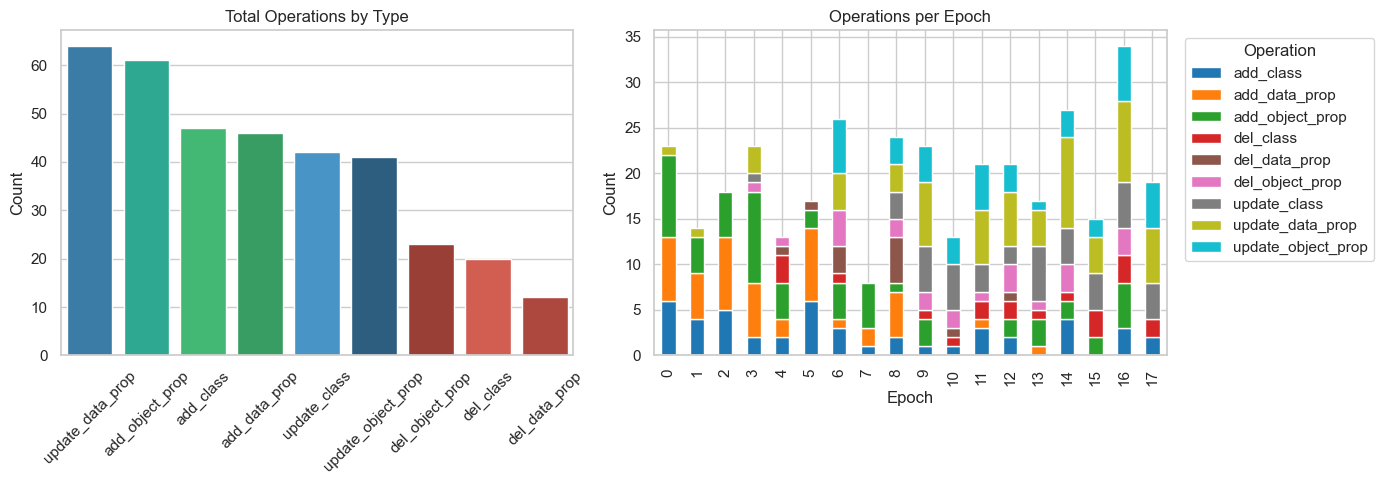

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall operation distribution
op_counts = df_operations['op_type'].value_counts()
colors = {
    'add_class': '#2ecc71', 'add_data_prop': '#27ae60', 'add_object_prop': '#1abc9c',
    'update_class': '#3498db', 'update_data_prop': '#2980b9', 'update_object_prop': '#1f618d',
    'del_class': '#e74c3c', 'del_data_prop': '#c0392b', 'del_object_prop': '#a93226',
    'merge_classes': '#9b59b6'
}
palette = [colors.get(op, '#95a5a6') for op in op_counts.index]
sns.barplot(x=op_counts.index, y=op_counts.values, ax=axes[0], palette=palette)
axes[0].set_title('Total Operations by Type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Operations per epoch (stacked)
op_pivot = df_operations.groupby(['epoch', 'op_type']).size().unstack(fill_value=0)
op_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Operations per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Count')
axes[1].legend(title='Operation', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Change Metrics Over Time

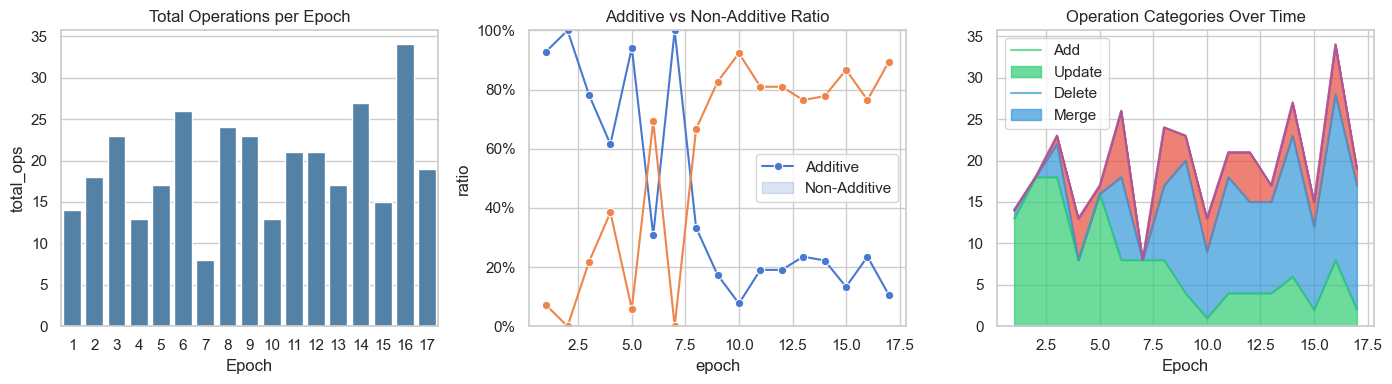

In [13]:
if len(df_changes) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Total operations per epoch
    sns.barplot(data=df_changes, x='epoch', y='total_ops', ax=axes[0], color='steelblue')
    axes[0].set_title('Total Operations per Epoch')
    axes[0].set_xlabel('Epoch')

    # Add vs Non-additive ratio
    df_ratio = df_changes.melt(id_vars=['epoch'], value_vars=['add_ratio', 'non_additive_ratio'],
                                var_name='ratio_type', value_name='ratio')
    sns.lineplot(data=df_ratio, x='epoch', y='ratio', hue='ratio_type', ax=axes[1], marker='o')
    axes[1].set_title('Additive vs Non-Additive Ratio')
    axes[1].set_ylim(0, 1)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    axes[1].legend(title='', labels=['Additive', 'Non-Additive'])

    # Stacked area: add/update/delete/merge
    df_stacked = df_changes[['epoch', 'total_add', 'total_update', 'total_delete', 'total_merge']].set_index('epoch')
    df_stacked.plot(kind='area', stacked=True, ax=axes[2], alpha=0.7,
                    color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
    axes[2].set_title('Operation Categories Over Time')
    axes[2].set_xlabel('Epoch')
    axes[2].legend(title='', labels=['Add', 'Update', 'Delete', 'Merge'])

    plt.tight_layout()
    plt.show()
else:
    print("No change metrics available (need at least 2 epochs)")

## Summary Statistics

In [14]:
# Final ontology stats
if len(df_structural) > 0:
    final = df_structural.iloc[-1]
    print("=== Final Ontology ===")
    print(f"Classes: {int(final['class_count'])} ({int(final['root_class_count'])} roots, {int(final['leaf_class_count'])} leaves)")
    print(f"Properties: {int(final['data_property_count'])} data, {int(final['object_property_count'])} object")
    print(f"Max depth: {int(final['max_depth'])}, Avg branching: {final['avg_branching_factor']:.2f}")
    print(f"Property coverage: {final['property_coverage']:.1%}")
    print(f"Orphan classes: {int(final['orphan_class_count'])}")
    print()

# Overall operation stats
if len(df_operations) > 0:
    print("=== Operations Summary ===")
    op_summary = df_operations['op_type'].value_counts()
    total = len(df_operations)
    adds = sum(op_summary.get(op, 0) for op in ['add_class', 'add_data_prop', 'add_object_prop'])
    updates = sum(op_summary.get(op, 0) for op in ['update_class', 'update_data_prop', 'update_object_prop'])
    deletes = sum(op_summary.get(op, 0) for op in ['del_class', 'del_data_prop', 'del_object_prop'])
    merges = op_summary.get('merge_classes', 0)
    print(f"Total operations: {total}")
    print(f"  Add: {adds} ({adds/total:.1%})")
    print(f"  Update: {updates} ({updates/total:.1%})")
    print(f"  Delete: {deletes} ({deletes/total:.1%})")
    print(f"  Merge: {merges} ({merges/total:.1%})")

=== Final Ontology ===
Classes: 28 (16 roots, 22 leaves)
Properties: 35 data, 38 object
Max depth: 2, Avg branching: 4.50
Property coverage: 55.6%
Orphan classes: 9

=== Operations Summary ===
Total operations: 356
  Add: 154 (43.3%)
  Update: 147 (41.3%)
  Delete: 55 (15.4%)
  Merge: 0 (0.0%)


## Growth Trajectory

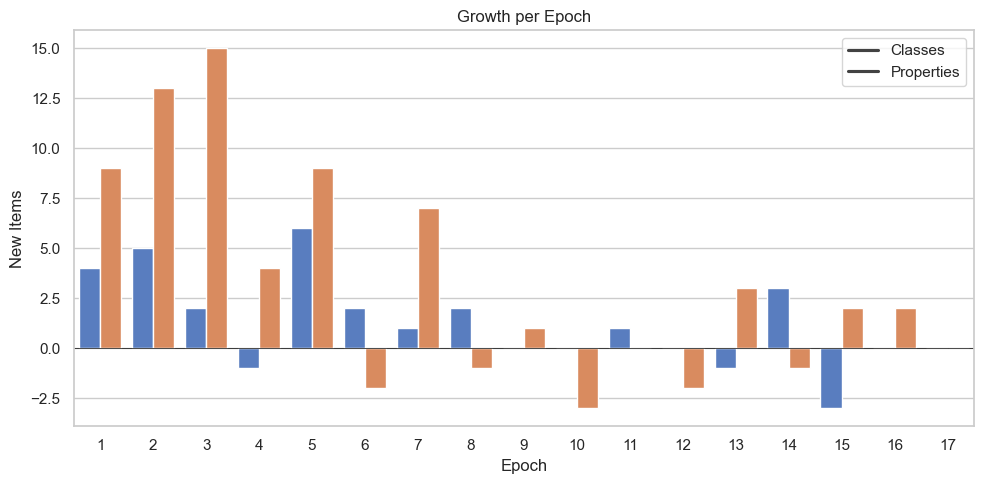

In [15]:
if len(df_structural) > 1:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Compute growth rates
    df_structural['class_growth'] = df_structural['class_count'].diff()
    df_structural['prop_growth'] = (df_structural['data_property_count'] + df_structural['object_property_count']).diff()
    
    df_growth = df_structural.melt(id_vars=['epoch'], value_vars=['class_growth', 'prop_growth'],
                                    var_name='metric', value_name='growth')
    df_growth = df_growth.dropna()
    
    sns.barplot(data=df_growth, x='epoch', y='growth', hue='metric', ax=ax)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title('Growth per Epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('New Items')
    ax.legend(title='', labels=['Classes', 'Properties'])
    
    plt.tight_layout()
    plt.show()